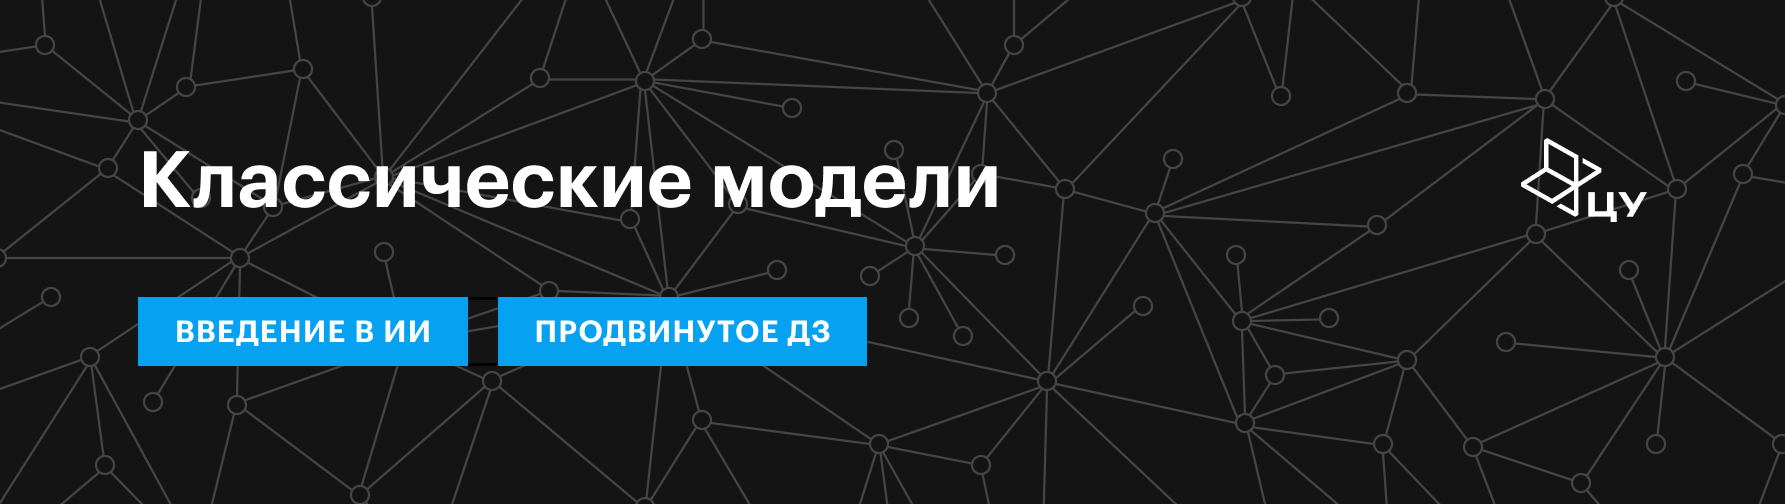

# Домашнее задание по теме «Решающее дерево для классификации c двумя признаками»

В этом задании ты:
- с нуля реализуешь решающее дерево для задачи бинарной классификации;
- добавишь ограничение `max_depth`;
- сравнишь два критерия разбиения — Gini и Entropy;
- увидишь, как глубина влияет на переобучение.



> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.

## Общий алгоритм построения решающего дерева

Рассмотрим пошаговый «каркас» алгоритма, который ты реализуешь для обучения дерева.

<!--1. Пусть в узле находятся объекты `(X_node, y_node)`.
2. Посчитать предсказываемый класс узла: `pred = majority(y_node)`.
3. Проверить условия остановки:
   - все объекты одного класса (`y_node` константен), или
   - достигли ограничения `max_depth`, или
   - не удаётся улучшить критерий (нет подходящего разбиения).
   Тогда вернуть лист: `Node(predicted_class=pred)`.
4. Для каждого признака `j ∈ {0, 1}`:
   - отсортировать уникальные значения `X_node[:, j]`;
   - сгенерировать кандидаты порогов `threshold` как середины между соседними уникальными значениями;
   - для каждого `threshold` разбить данные на `left/right` по правилу `x[j] <= threshold`;
   - посчитать **взвешенную загрязненность листа** (weighted impurity) по выбранному критерию.
5. Выбрать `(j*, threshold*)`, которые минимизируют взвешенную загрязненность (или, эквивалентно, максимизируют gain).
6. Создать внутренний узел `Node(feature_index=j*, threshold=threshold*)` и рекурсивно построить `left/right`.
7. Вернуть корневой узел.-->

1. Пусть в узле находятся объекты: `(X_node, y_node)`.

2. Посчитай предсказываемый класс узла: `pred = majority(y_node)`.

3. Проверь условия остановки. Алгоритм прекращает работу, если выполнено одно из условий:
   - все объекты одного класса — `y_node` константен,
   - достигли ограничения `max_depth`,
   - не удаётся улучшить критерий — нет подходящего разбиения.
   
    При выполнении условия алгоритм возвращает лист: `Node(predicted_class=pred)`.

4. Для каждого признака `j ∈ {0, 1}`:
   - отсортируй уникальные значения `X_node[:, j]`;
   - сгенерируй кандидаты порогов `threshold` как середины между соседними уникальными значениями;
   - для каждого `threshold` разбей данные на `left/right` по правилу `x[j] <= threshold`;
   - посчитай взвешенную загрязнённость листа (weighted impurity) по выбранному критерию.

5. Выбери `(j*, threshold*)`, которые минимизируют взвешенную загрязнённость или эквивалентно максимизируют gain.

6. Создай внутренний узел `Node(feature_index=j*, threshold=threshold*)` и рекурсивно построй `left/right`.

7. Верни корневой узел.


### Критерии загрязнённости

Алгоритм построения решающего дерева на каждом шаге выбирает лучшее разбиение данных. Чтобы определить качество каждого разбиения, алгоритм использует «критерии загрязнённости».

Рассмотрим два критерия загрязнённости — Entropy и Gini. Пусть в узле $S$ доля класса $k$ равна $p_k$.

**Энтропия (Entropy):**
$$H(S) = -\sum_{k} p_k \log_2 p_k.$$

**Критерий Джинни (Gini):**
$$G(S) = 1 - \sum_{k} p_k^2.$$


В качестве функции $I(...)$ можно использовать энтропию или критерий Джинни. Это поможет определить **взвешенную загрязнённость разбиения** — оценить, насколько «грязными» являются левый и правый листы дерева в совокупности, чтобы выбрать наилучшее разбиение.

**Взвешенная загрязнённость:**

$$I_{split} = \frac{|S_L|}{|S|} I(S_L) + \frac{|S_R|}{|S|} I(S_R),$$
где
-  $|S|$ — количество объектов во всей разбиваемой выборке;
- $|S_L|$ — количество объектов в левой части дерева;
- $|S_R|$ — количество объектов в правой части дерева.

При построении дерева выбирают такое разбиение, при котором значение $I_{split}$ минимально.

In [77]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional, Literal, Tuple

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(42)


### Описание узла дерева

После выбора критерия загрязнённости и поиска оптимального разбиения алгоритм создаёт новые узлы дерева. Рассмотрим структуру узла дерева и его основные поля.

Структура `Node`.

Если узел — лист, то:
- у него заполнен `predicted_class`;
- `feature_index/threshold/left/right` — пустые.

Если узел — внутренний, то:
- у него есть `feature_index`, `threshold`, `left`, `right`;
- храним `predicted_class`.


In [78]:
@dataclass
class Node:
    # Для внутреннего узла:
    feature_index: Optional[int] = None   # 0 или 1
    threshold: Optional[float] = None

    left: Optional["Node"] = None
    right: Optional["Node"] = None

    # Для листа и как «предсказание по умолчанию» в узле:
    predicted_class: Optional[int] = None

    depth: int = 0


### Задание 1 [3 балла]

Реализуй:

1. `majority_class(y)` — наиболее частый класс (при равенстве можно выбирать 0) **[0,5 балла].**
2. `entropy(y)` — индекс смешанности классов Энтропия для массива меток `y` **[1 балл].**

    >**Подсказка.** Логарифм бери `log2` и аккуратно обработай`p=0`, чтобы не получить `log(0)`

3. `gini(y)` — индекс смешанности классов Джинни для массива меток `y` **[1 балл].**
4. `weighted_impurity(y_left, y_right, criterion)` — взвешенную загрязнённость разбиения **[0,5 балла].**

Считай, что `y` содержит только `0/1`.


In [79]:
def entropy(y: np.ndarray) -> float:
    p0 = (len(y) - np.sum(y)) / len(y)
    p1 = np.sum(y) / len(y)
    h = 0.0
    if p0 != 0:
      h -= p0 * np.log2(p0)
    if p1 != 0:
      h -= p1 * np.log2(p1)
    return h


In [80]:
def majority_class(y: np.ndarray) -> int:
    return len(y) - np.sum(y) < np.sum(y)

def gini(y: np.ndarray) -> float:
    p0 = (len(y) - np.sum(y)) / len(y)
    p1 = np.sum(y) / len(y)
    return 1 - p0 ** 2 - p1 ** 2

def weighted_impurity(
    y_left: np.ndarray,
    y_right: np.ndarray,
    criterion: Literal["gini", "entropy"] = "gini",
) -> float:
    n = len(y_left) + len(y_right)
    if criterion == "gini":
      return len(y_left) / n * gini(y_left) + len(y_right) / n * gini(y_right)
    else:
      return len(y_left) / n * entropy(y_left) + len(y_right) / n * entropy(y_right)
    # Взвешенная загрязнённость после разбиения (・`ω´・)
    # Напиши код здесь


In [81]:
entropy([0, 0, 0, 0])

np.float64(0.0)

In [82]:
# Тесты

# Entropy
assert entropy([0, 0, 0, 0]) == 0.0
assert entropy([1, 1, 1]) == 0.0

# Majority_class
assert majority_class([0, 0, 0]) == 0
assert majority_class([1, 1, 1, 0]) == 1
assert majority_class([0, 1]) == 0                      # Равенство

# Gini
assert np.isclose(gini([0, 1]), 0.5)                    # 1 — (0.25 + 0.25) = 0.5
assert np.isclose(gini([0, 0, 0, 1]), 0.375)            # p1 = 0.25 -> 1 — (0.5625 + 0.0625) = 0.375

# Weighted_impurity (gini)
yl, yr = np.array([0, 0]), np.array([1, 1])
assert np.isclose(weighted_impurity(yl, yr, "gini"), 0.0)

yl, yr = np.array([0, 1]), np.array([0, 0])
# Слева: gini=0.5, справа: gini=0, 2/4 и 2/4 -> 0.25
assert np.isclose(weighted_impurity(yl, yr, "gini"), 0.25)

# Weighted_impurity (entropy)
yl, yr = np.array([0, 1]), np.array([0, 0])
# Слева: entropy=1, справа: entropy=0, 2/4 и 2/4 -> 0.5
assert np.isclose(weighted_impurity(yl, yr, "entropy"), 0.5)

print("Все тесты пройдены, ура!")



Все тесты пройдены, ура!


### Задание 2 [2 балла]

Реализуй функцию `best_split(X, y, criterion)`, где `X` имеет форму `(n_samples, 2)`:
- для каждого признака `j`:
  - отсортируй уникальные значения `X[:, j]`,
  - для кандидатов порога возьми середины между соседними значениями;
- для каждого порога — вычисли `weighted_impurity`;
- верни `best_feature_index`, `best_threshold`, `best_impurity`;
- если разбиение невозможно, например, все значения признаков одинаковые, — верни `(None, None, +inf)`.


In [83]:
def best_split(
    X: np.ndarray,
    y: np.ndarray,
    criterion: Literal["gini", "entropy"] = "gini",
) -> Tuple[Optional[int], Optional[float], float]:
    # Ищет лучшее разбиение по двум признакам
    best_feature = None
    best_threshold = None
    best_score = np.inf

    for i in range(X.shape[1]):
      k = sorted(np.unique(X[:,i]))
      for j in range(1, len(k)):
        split = (k[j - 1] + k[j]) / 2

        mask = X[:, i] < split
        left = y[mask]
        right = y[~mask]
        weight = weighted_impurity(left, right, criterion)

        if weight < best_score:
          best_feature = i
          best_threshold = split
          best_score = weight


    return best_feature, best_threshold, best_score


In [84]:
# Тестики

# Идеально разделяем по x1 (признак 1): слева все 0, справа все 1 -> score = 0
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [0.0, 2.0],
    [0.0, 3.0],
])
y = np.array([0, 0, 1, 1])

bf, thr, score = best_split(X, y, criterion="gini")
assert bf == 1
assert np.isclose(thr, 1.5)          # Середина между 1 и 2
assert np.isclose(score, 0.0)


# Выбирается правильный признак: x0 даёт идеальный сплит, x1 шумит
X = np.array([
    [0.0,  10.0],
    [0.0,  -3.0],
    [1.0,   2.0],
    [1.0, 100.0],
])
y = np.array([0, 0, 1, 1])

bf, thr, score = best_split(X, y, criterion="gini")
assert bf == 0
assert np.isclose(thr, 0.5)
assert np.isclose(score, 0.0)

print("Все тесты пройдены, ура!")


Все тесты пройдены, ура!


### Задание 3 [2 балла]

Реализуй рекурсивное построение дерева — `build_tree(X, y, depth=0, criterion="gini")` со следующими условиями остановки:
- все объекты в узле одного класса;
- `best_split` не нашёл разбиение — вернул `None`;
- разбиение не улучшает ситуацию — `best_score >= current_impurity`.

На выходе — корневой `Node`.


In [85]:
def build_tree(
    X: np.ndarray,
    y: np.ndarray,
    depth: int = 0,
    criterion: Literal["gini", "entropy"] = "gini",
) -> Node:
    # Дефолтное предсказание
    pred = majority_class(y)

    # Создаём узел сразу: даже если это лист, в нём будет predicted_class
    node = Node(predicted_class=pred, depth=depth)

    # Напиши код здесь — далее комментариями дан набросок действий, можешь следовать ему или реализовать построение дерева иначе
    # Ниже будет дан ассерt

    # Выбираем критерий

    # Ищем лучшее разбиение
    bf, thr, score = best_split(X, y, criterion)

    # Если не нашли наилучшего разбиения — останавливаем алгоритм
    if bf == None:
      return node

    # Если разбиение не улучшило ситуацию — останавливаем алгоритм (при равенстве не бьём дальше)
    par_im = 0
    if criterion == "gini":
      par_im = gini(y)
    else:
      par_im = entropy(y)
    if score >= par_im:
      return node



    # Разбиваем данные
    mask = X[:, bf] < thr

    # На всякий случай: если вдруг получилось пустое поддерево — останавливаемся
    if (np.sum(mask) == 0) | (np.sum(mask) == len(y)):
      return node

    # Заполняем параметры внутреннего узла и строим поддеревья
    node.feature_index = bf
    node.threshold = thr

    node.left = build_tree(X[mask], y[mask], depth + 1, criterion)
    node.right = build_tree(X[~mask], y[~mask], depth + 1, criterion)

    return node

In [86]:
import numpy as np

# Идеально разделяемые данные по признаку 0 порогом 0.5
X = np.array([
    [0.0],
    [0.0],
    [1.0],
    [1.0],
])
y = np.array([0, 0, 1, 1])

tree = build_tree(X, y, criterion="gini")

assert (
    tree.feature_index == 0
    and np.isclose(tree.threshold, 0.5)
    and tree.left is not None and tree.right is not None
    and tree.left.predicted_class == 0
    and tree.right.predicted_class == 1
)

print("Тест пройден успешно, ура!")


Тест пройден успешно, ура!


### Задание 4 [1 балл]

Реализуй:
- `predict_one(x, node)` — строит предсказание для одного объекта **[0,5 балла]**;
- `predict(X, node)` — применяет `predict_one` ко всем объектам **[0,5 балла]**.


In [87]:
def predict_one(x: np.ndarray, node: Node) -> int:
    if node.left is None and node.right is None:
        return node.predicted_class

    if x[node.feature_index] < node.threshold:
        return predict_one(x, node.left)
    else:
        return predict_one(x, node.right)


def predict(X: np.ndarray, node: Node) -> np.ndarray:
    return np.array([predict_one(x, node) for x in X])


### Задание 5  [1 балл]

<!--Модифицируйте построение дерева так, чтобы оно принимало `max_depth: INT.

- Если `max_depth` задан и `depth == max_depth`, то узел должен стать листом.
- При этом в листе должен быть корректный `predicted_class` (majority).

Создайте новую функцию `build_tree_max_depth(...)` -->

1. Модифицируй построение дерева так, чтобы оно принимало `max_depth: INT`:

    - если `max_depth` задан и `depth == max_depth`, то узел должен стать листом;
    - в листе должен быть корректный `predicted_class` (majority).

2. Создай новую функцию `build_tree_max_depth(...)`.


In [95]:
def build_tree_max_depth(
    X: np.ndarray,
    y: np.ndarray,
    max_depth: Optional[int] = None,
    depth: int = 0,
    criterion: Literal["gini", "entropy"] = "gini",
) -> Node:
    pred = majority_class(y)

    # Создаём узел сразу: даже если это лист, в нём будет predicted_class
    node = Node(predicted_class=pred, depth=depth)

    # Напиши код здесь — далее комментариями дан набросок действий, можешь следовать ему или реализовать построение дерева иначе
    # Ниже будет дан ассерt
    if max_depth is not None and depth >= max_depth:
      return node
    # Выбираем критерий

    # Ищем лучшее разбиение
    bf, thr, score = best_split(X, y, criterion)

    if bf is None:
        return node

    if score <= 0:
        return node

    # Если разбиение не улучшило ситуацию — останавливаем алгоритм (при равенстве не бьём дальше)
    par_im = 0
    if criterion == "gini":
      par_im = gini(y)
    else:
      par_im = entropy(y)
    if score >= par_im:
      return node



    # Разбиваем данные
    mask = X[:, bf] < thr

    # На всякий случай: если вдруг получилось пустое поддерево — останавливаемся
    if (np.sum(mask) == 0) | (np.sum(mask) == len(y)):
      return node

    # Заполняем параметры внутреннего узла и строим поддеревья
    node.feature_index = bf
    node.threshold = thr

    node.left = build_tree_max_depth(X[mask], y[mask], max_depth, depth + 1, criterion)
    node.right = build_tree_max_depth(X[~mask], y[~mask], max_depth, depth + 1, criterion)

    return node
    # Напиши код здесь


In [89]:
# При помощи данной функции ты можешь проверить, как работает твоя функция

def plot_decision_regions(
    X: np.ndarray,
    y: np.ndarray,
    root: Node,
    title: str = "",
    step: float = 0.02,
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    zz = predict(grid, root).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=30)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


toy acc: 0.8333333333333334


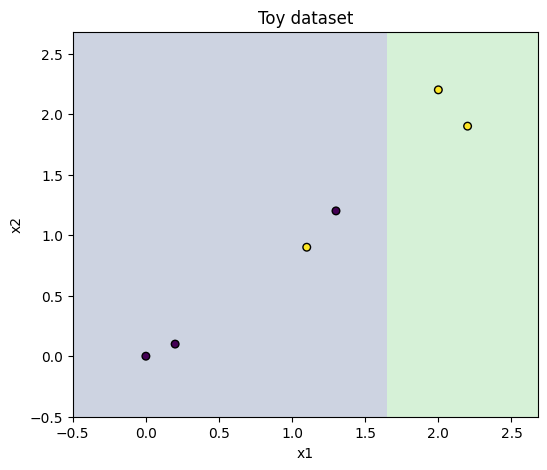

In [90]:
# Можешь менять параметры точек и смотреть, как меняется дерево

X_toy = np.array([[0.0, 0.0],
   [0.2, 0.1],
  [1.3, 1.2],
   [1.1, 0.9],
     [2.0, 2.2],
     [2.2, 1.9],
 ])
y_toy = np.array([0, 0, 0, 1, 1, 1])
root = build_tree_max_depth(X_toy, y_toy, max_depth=2, criterion="gini")
print("toy acc:", accuracy_score(y_toy, predict(X_toy, root)))
plot_decision_regions(X_toy, y_toy, root, title="Toy dataset")


### Задание 6 [0,5 балла]

1) Сгенерируй данные `make_moons`. Например, `noise=0.25`, `n_samples=600`.
2) Раздели данные на train/test.
3) Обучи дерево с разными `max_depth`.
4) Для нескольких глубин нарисуй границу решений и посчитай accuracy на train/test.

Сделай выводы:
- Как ведёт себя переобучение при росте глубины?
- Что происходит с границей решений?


depth=1, train_acc=0.831, test_acc=0.858


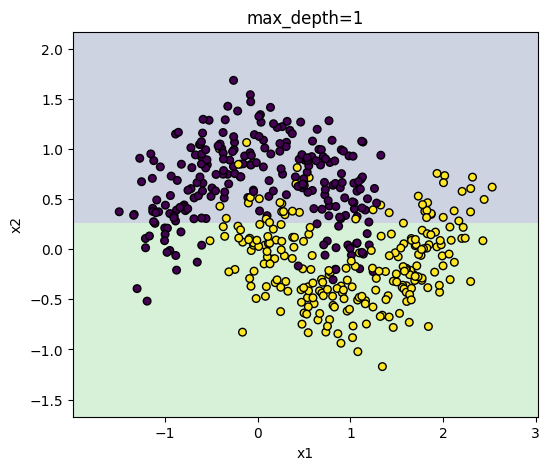

depth=2, train_acc=0.910, test_acc=0.933


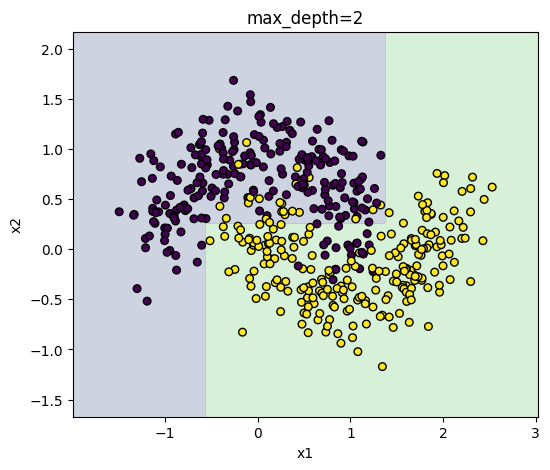

depth=3, train_acc=0.910, test_acc=0.933


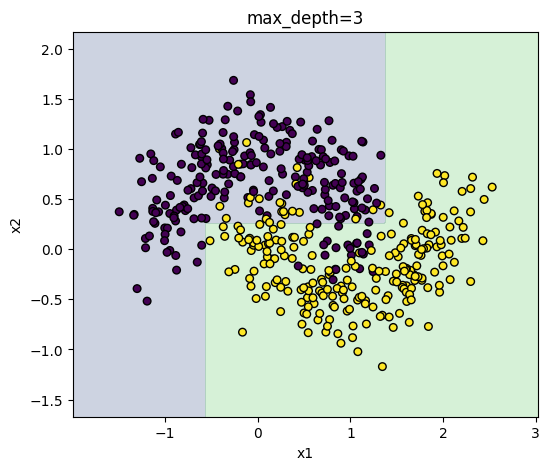

depth=5, train_acc=0.956, test_acc=0.933


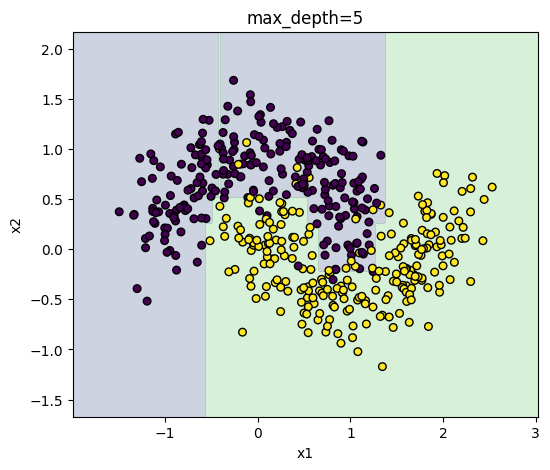

depth=10, train_acc=0.979, test_acc=0.933


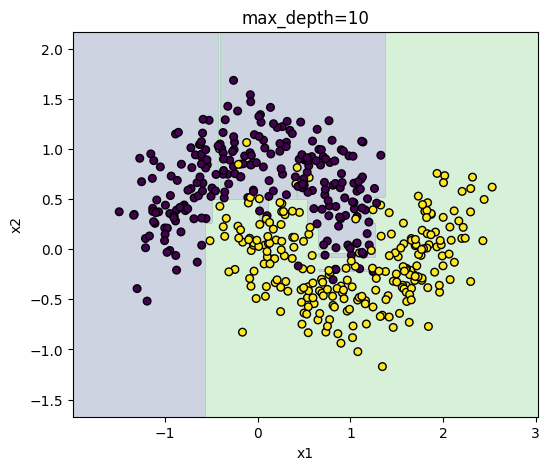

depth=None, train_acc=0.979, test_acc=0.933


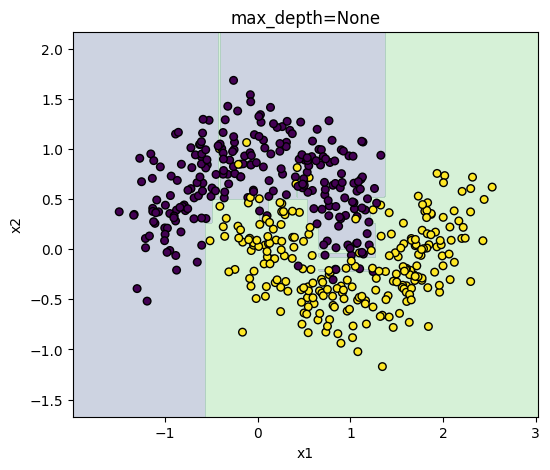

In [96]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8,
)

depths = [1, 2, 3, 5, 10, None]

for d in depths:
    root = build_tree_max_depth(
        X_train, y_train, max_depth=d, criterion="gini"
    )

    train_acc = accuracy_score(y_train, predict(X_train, root))
    test_acc = accuracy_score(y_test, predict(X_test, root))

    print(f"depth={d} train acc={train_acc:.3f} test acc={test_acc:.3f}")

    plot_decision_regions(
        X_train,
        y_train,
        root,
        title=f"max_depth={d}"
    )

При увеличении глубины дерево все сильнее переобучается, разделяя плоскость на более мелкие куски, из-за чего граница решений становится все более фрагментированной

### Задание 7 [0,5 балла]

Критерии часто приводят похожие разбиения, особенно на больших выборках. Но существуют небольшие наборы данных, где в зависимости от критерия дерево выберет разные пороги.

Проверь это утверждение.

1. Обучи дерево на данных ниже, глубину выбери самостоятельно:
   - один раз — с `criterion="gini"`;
   - один раз — с `criterion="entropy"`.
2. Выведи `(feature_index, threshold)` для корня в каждом случае.
3. Объясни, как ведут себя деревья с разными критериями.

In [100]:

X_cmp = np.array([
    [3., 2.],
    [1., 3.],
    [2., 2.],
    [0., 3.],
    [0., 2.],
    [0., 0.],
    [3., 1.],
    [1., 2.],
])

y_cmp = np.array([0, 1, 1, 0, 0, 1, 1, 1])

tree_gini = build_tree_max_depth(
    X_cmp, y_cmp, max_depth=3, criterion="gini"
)

tree_entropy = build_tree_max_depth(
    X_cmp, y_cmp, max_depth=3, criterion="entropy"
)

print("Gini ",
      tree_gini.feature_index,
      tree_gini.threshold)

print("Entropy ",
      tree_entropy.feature_index,
      tree_entropy.threshold)

Gini  0 0.5
Entropy  1 1.5


Напиши свои мысли здесь.